## Pre - Processing 

### Patient-Based Partitioning 
- The BEED dataset from the UCI repository is in a tabular format, so every 100 lines represents one patient. Patient-Based Partitioning will be used to ensure that a patient doesn't end up in more than one place. 

### Channel-Wise Z-Score Normalization
- EEG amplitude levels natively vary across channels, so unscaled features can distort weight updates and slow down training. Standardization centers the data $(X_{\text{norm}} = \frac{X - \mu}{\sigma})$ so every channel contributes equally to gradient descent.


In [56]:
# import everything need
import pandas as pd 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch 
from torch.utils.data import DataLoader, TensorDataset
scaler = StandardScaler()
from torch import nn
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.metrics import accuracy_score
import copy

## Creating Patient ID

In [57]:

# Load data into a DataFrame
df = pd.read_csv("BEED_Data.csv")

# Create a 'Patient_ID' column
df['Patient_ID'] = df.index // 100 + 1

# Define the target column name
target_column = 'y'

print(f"Data loaded successfully: {len(df)} rows, {df['Patient_ID'].nunique()} patients")


Data loaded successfully: 8000 rows, 80 patients


## Separating Train/Test/Validation Sets and Checking for Overlap

In [58]:

# Extract unique patient IDs and their corresponding labels
patient_df = df.groupby('Patient_ID')['y'].first().reset_index()

# Isolate the 15% Test Patients (12 patients: 3 per class)
train_val_patients, test_patients = train_test_split(patient_df, test_size=12, random_state=42, stratify=patient_df['y'])

# Divide up the Train/Validation Set (70% Train, 15% Validation)
train_patients, val_patients = train_test_split(train_val_patients, test_size=12, random_state=42, stratify=train_val_patients['y'])

# filter the original DataFrame by patient assignments
train_df = df[df['Patient_ID'].isin(train_patients['Patient_ID'])].reset_index(drop=True)
val_df = df[df['Patient_ID'].isin(val_patients['Patient_ID'])].reset_index(drop=True)
test_df = df[df['Patient_ID'].isin(test_patients['Patient_ID'])].reset_index(drop=True)


# Extract Patient IDs for Leakage Check
train_p_set = set(train_df['Patient_ID'])
val_p_set = set(val_df['Patient_ID'])
test_p_set = set(test_df['Patient_ID'])

# Trigger error if there are overlapping patients
assert (
    len(train_p_set.intersection(val_p_set)) == 0
    and len(train_p_set.intersection(test_p_set)) == 0
    and len(val_p_set.intersection(test_p_set)) == 0
), "Overlap between Train, Validation, and Test sets"

print("No overlapping patients between Train, Validation, and Test sets. Data splitting successful.")

# Print verification summary 
print("--- Patient Distribution Summary ---")
print(
    f"Train:      {len(train_p_set)} patients ({len(train_df)} rows,"
    f" {len(train_df)/len(df):.0%})"
)
print(
    f"Validation: {len(val_p_set)} patients ({len(val_df)} rows,"
    f" {len(val_df)/len(df):.0%})"
)
print(
    f"Test:       {len(test_p_set)} patients ({len(test_df)} rows,"
    f" {len(test_df)/len(df):.0%})"
)

print("\n--- CLASS DISTRIBUTION IN TEST SET ---")
print(test_df[target_column].value_counts().sort_index())


No overlapping patients between Train, Validation, and Test sets. Data splitting successful.
--- Patient Distribution Summary ---
Train:      56 patients (5600 rows, 70%)
Validation: 12 patients (1200 rows, 15%)
Test:       12 patients (1200 rows, 15%)

--- CLASS DISTRIBUTION IN TEST SET ---
y
0    300
1    300
2    300
3    300
Name: count, dtype: int64


## Defining Target column and Features columns and Creating Tensors/Loaders

In [59]:
# Define target column and feature columns
target_column = 'y'
feature_columns = [col for col in df.columns if col != target_column and col != 'Patient_ID']

# fit scaler ONLY on training data to prevent data leakage
X_train= scaler.fit_transform(train_df[feature_columns].values)
y_train = train_df[target_column].values

X_val = scaler.transform(val_df[feature_columns].values)
y_val = val_df[target_column].values

X_test = scaler.transform(test_df[feature_columns].values)
y_test = test_df[target_column].values

# Convert the scaled data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Save test tensors
torch.save({"X_test": X_test_tensor, "y_test": y_test_tensor}, "processed_test_data.pt")

train_loader = DataLoader(TensorDataset(X_train_tensor, y_train_tensor), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_val_tensor, y_val_tensor), batch_size=64, shuffle=False)
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64, shuffle=False)

print("Data loading complete. Train, Validation, and Test DataLoaders are ready.")

Data loading complete. Train, Validation, and Test DataLoaders are ready.


## Model Architectures

In [60]:
class MLP_1Layer(nn.Module):
    def __init__(self, dropout_rate=0):
        # 1 Hidden Layer MLP (16 inputs -> 128 hidden units -> 4 classes)
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 128),
            nn.LeakyReLU(negative_slope=0.01), 
            nn.Dropout(p=dropout_rate),
            nn.Linear(128, 4)
        )

    def forward(self, x):
        return self.network(x)


class MLP_2Layer(nn.Module):
    def __init__(self):
        # 2 Hidden Layer MLP - Baseline Architecture (16 -> 128 -> 64 -> 4)
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 4)
        )

    def forward(self, x):
        return self.network(x)


class MLP_3Layer(nn.Module):
    def __init__(self):
        # 3 Hidden Layer MLP (16 -> 128 -> 64 -> 32 -> 4)
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(16, 128),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(128, 64),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(64, 32),
            nn.LeakyReLU(negative_slope=0.01),
            nn.Linear(32, 4)
        )

    def forward(self, x):
        return self.network(x)


## Reusable Pipeline & Evaluation Function

In [ ]:

global_best_test_loss = float("inf")
best_model_path = "global_best_model.pt"

def run_experiment(
    model,
    lr=0.001,
    batch_size=64,
    epochs=50,
    patience=7,
    exp_title="Model Experiment",
    weight_decay=0.0,
    checkpoint_path=None,
):
    global global_best_test_loss

    if checkpoint_path is None:
        checkpoint_path = best_model_path

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay,
    )

    best_val_loss = float("inf")
    best_epoch = 0
    best_model_weights = copy.deepcopy(model.state_dict())
    patience_counter = 0

    train_losses = []
    val_losses = []

    print(
        f"=== Running Experiment: {exp_title} "
        f"(Batch Size: {batch_size}, LR: {lr}, WD: {weight_decay}) ==="
    )

    for epoch in range(1, epochs + 1):
        model.train()
        running_train_loss = 0.0

        for inputs, targets in train_loader:
            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_train_loss += loss.item() * inputs.size(0)

        epoch_train_loss = running_train_loss / len(train_loader.dataset)
        train_losses.append(epoch_train_loss)

        model.eval()
        running_val_loss = 0.0

        with torch.no_grad():
            for inputs, targets in val_loader:
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                running_val_loss += loss.item() * inputs.size(0)

        epoch_val_loss = running_val_loss / len(val_loader.dataset)
        val_losses.append(epoch_val_loss)

        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            best_epoch = epoch
            best_model_weights = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stopping triggered at epoch {epoch}.")
            break

    model.load_state_dict(best_model_weights)
    model.eval()

    all_test_preds = []
    all_test_targets = []
    running_test_loss = 0.0

    with torch.no_grad():
        for inputs, targets in test_loader:
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            running_test_loss += loss.item() * inputs.size(0)

            preds = torch.argmax(outputs, dim=1)
            all_test_preds.extend(preds.cpu().numpy())
            all_test_targets.extend(targets.cpu().numpy())

    test_loss = running_test_loss / len(test_loader.dataset)
    test_acc = accuracy_score(all_test_targets, all_test_preds)
    test_f1 = f1_score(
        all_test_targets,
        all_test_preds,
        average="macro",
    )

    print(f"Results for '{exp_title}' (Best Epoch: {best_epoch}):")
    print(
        f"Test Accuracy: {test_acc:.4f} | "
        f"Test Macro F1: {test_f1:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

    if test_loss < global_best_test_loss:
        print(
            f"New global best: "
            f"{global_best_test_loss:.4f} -> {test_loss:.4f}"
        )

        global_best_test_loss = test_loss

        torch.save(
            {
                "state_dict": best_model_weights,
                "architecture": model.__class__,
                "dropout_rate": getattr(model, "dropout_rate", 0.0),
                "test_loss": test_loss,
                "exp_title": exp_title,
            },
            checkpoint_path,
        )

        print(f"Model saved to '{checkpoint_path}'.")
    else:
        print(
            f"Did not beat global best loss "
            f"({global_best_test_loss:.4f})."
        )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(all_test_targets, all_test_preds)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        ax=axes[0],
    )
    axes[0].set_title(f"Confusion Matrix: {exp_title}")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    epoch_ticks = list(range(1, len(train_losses) + 1))
    axes[1].plot(
        epoch_ticks,
        train_losses,
        label="Train Loss",
        color="blue",
    )
    axes[1].plot(
        epoch_ticks,
        val_losses,
        label="Validation Loss",
        color="orange",
    )
    axes[1].axvline(
        x=best_epoch,
        color="green",
        linestyle="--",
        label="Best Epoch",
    )
    axes[1].set_title(f"Loss Curve: {exp_title}")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

    return {
        "Experiment": exp_title,
        "Batch Size": batch_size,
        "Learning Rate": float(lr),
        "Best Epoch": best_epoch,
        "Test Acc": round(test_acc, 4),
        "Test Macro F1": round(test_f1, 4),
        "Test Loss": round(test_loss, 4),
        "model_object": model,
    }

# 01: Network Depth Experiments

## Overview & Objective
Having verified our data pipeline and established a baseline benchmark with a 2-hidden-layer MLP, this notebook explores how network depth impacts model capacity and feature resolution for EEG seizure classification. 

Specifically, we evaluate performance across three depth configurations:
* **1 Hidden Layer `[128]`:** Minimal non-linear capacity control.
* **2 Hidden Layers `[128, 64]` (Baseline):** Verified reference model (78.92% Test Accuracy / 0.7747 Macro F1).
* **3 Hidden Layers `[256, 128, 64]`:** Deeper hierarchical feature extraction.

All experiments maintain identical patient-level splits (70/15/15), `LeakyReLU` activations, and `AdamW` optimization parameters to isolate network depth as the primary independent variable.



=== Running Experiment: 1 Hidden Layer Baseline (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 35.
Results for '1 Hidden Layer Baseline' (Best Epoch: 28):
Test Accuracy: 0.8025 | Test Macro F1: 0.7927 | Test Loss: 0.6090
New global best: inf -> 0.6090
Model saved to 'global_best_model.pt'.


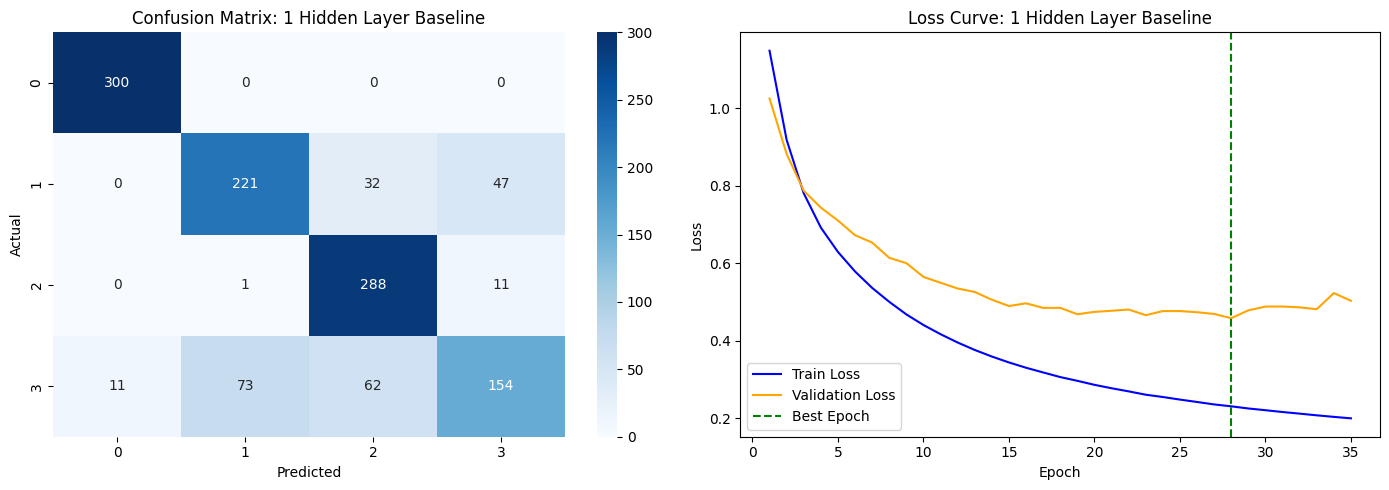

=== Running Experiment: 2 Hidden Layers Baseline (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 16.
Results for '2 Hidden Layers Baseline' (Best Epoch: 9):
Test Accuracy: 0.7967 | Test Macro F1: 0.7847 | Test Loss: 0.6244
Did not beat global best loss (0.6090).


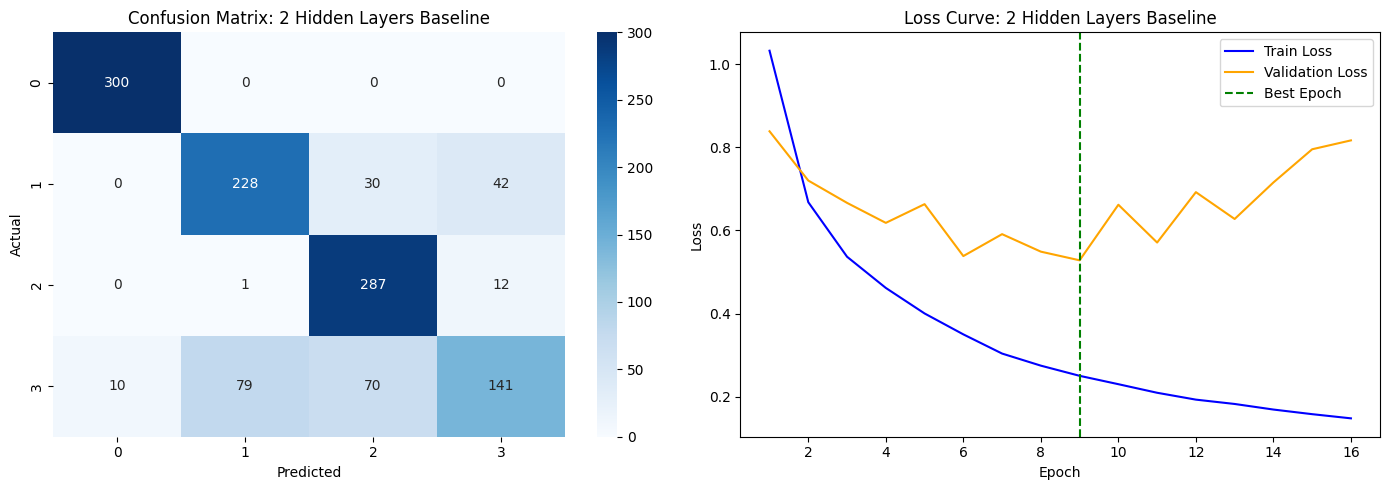

=== Running Experiment: 3 Hidden Layers Baseline (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 14.
Results for '3 Hidden Layers Baseline' (Best Epoch: 7):
Test Accuracy: 0.7733 | Test Macro F1: 0.7620 | Test Loss: 0.7419
Did not beat global best loss (0.6090).


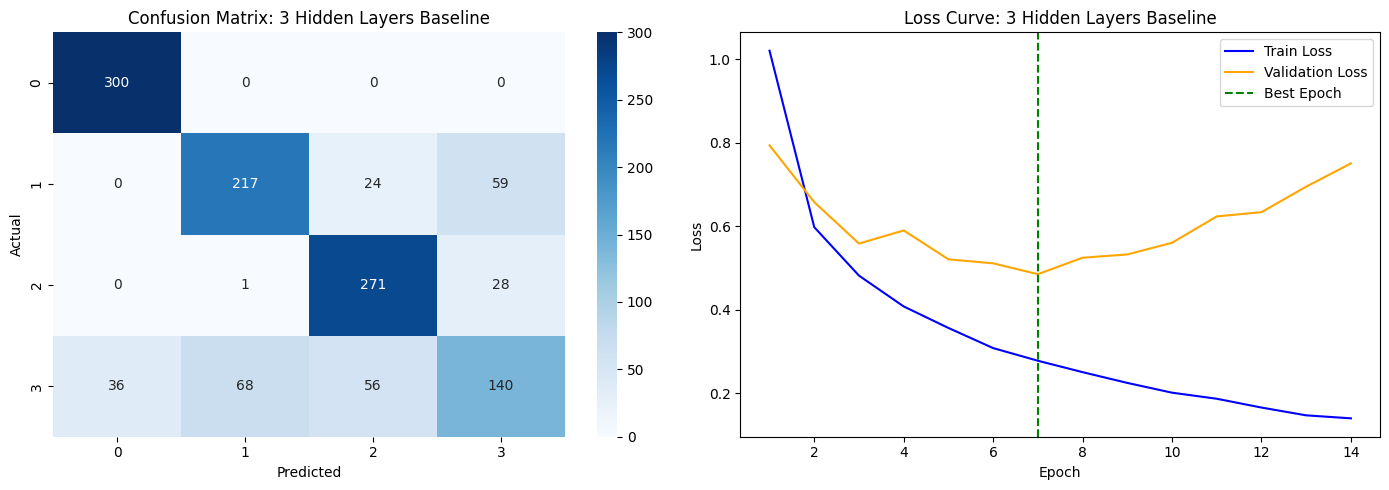

,Experiment,Batch Size,Learning Rate,Best Epoch,Test Acc,Test Macro F1,Test Loss,model_object
0,1 Hidden Layer Baseline,64,0.001,28,0.8025,0.7927,0.6090,MLP_1Layer(\n (network): Sequential(\n (0)...
1,2 Hidden Layers Baseline,64,0.001,9,0.7967,0.7847,0.6244,MLP_2Layer(\n (network): Sequential(\n (0)...
2,3 Hidden Layers Baseline,64,0.001,7,0.7733,0.7620,0.7419,MLP_3Layer(\n (network): Sequential(\n (0)...


In [62]:
# Reset tracker before starting fresh pipeline
global_best_test_loss = float("inf")

res_1layer = run_experiment(MLP_1Layer(), lr=0.001, exp_title="1 Hidden Layer Baseline")
res_2layer = run_experiment(MLP_2Layer(), lr=0.001, exp_title="2 Hidden Layers Baseline")
res_3layer = run_experiment(MLP_3Layer(), lr=0.001, exp_title="3 Hidden Layers Baseline")

arch_df = pd.DataFrame([res_1layer, res_2layer, res_3layer])
display(arch_df.sort_values(by="Test Loss", ascending=True))

## Choosing Architecture 

The 1 hidden layer MLP architecture is the chosen architechure, offering the highest accuracy and lowest validation and test loss. Adding more layers only caused the network to begin to overfit the data

# 02: Learning Rate Sensitivity Experiments

## Overview & Objective
In this section we will evaluate different architectures in choosing the best one based on accuracy and test loss. 

Specifically, we evaluate training dynamics and generalization performance across three learning rate orders of magnitude:
* **Default Learning Rate ($\eta = 0.001$):** Serves as our tuned reference benchmark
* **Low Learning Rate ($\eta = 0.0001$):** Tests whether smaller, conservative step sizes yield smoother convergence and higher test accuracy within the 50-epoch budget.
* **Mid Learning Rate ($\eta = 0.003$):** A slight alteration to the baseline 
* **High Learning Rate ($\eta = 0.01$):** Tests whether larger gradient updates accelerate convergence or induce loss oscillations and instability around local minima.

All experiments maintain fixed network architecture (`MLP_1Layer`), batch size (`64`), patient-level splits (70/15/15), and early stopping parameters (patience = 7) to isolate the learning rate as the primary independent variable.


=== Running Experiment: 1 Hidden Layer w/ 0.01 LR (Batch Size: 64, LR: 0.01, WD: 0.0) ===
Early stopping triggered at epoch 11.
Results for '1 Hidden Layer w/ 0.01 LR' (Best Epoch: 4):
Test Accuracy: 0.8075 | Test Macro F1: 0.7985 | Test Loss: 0.6599
Did not beat global best loss (0.6090).


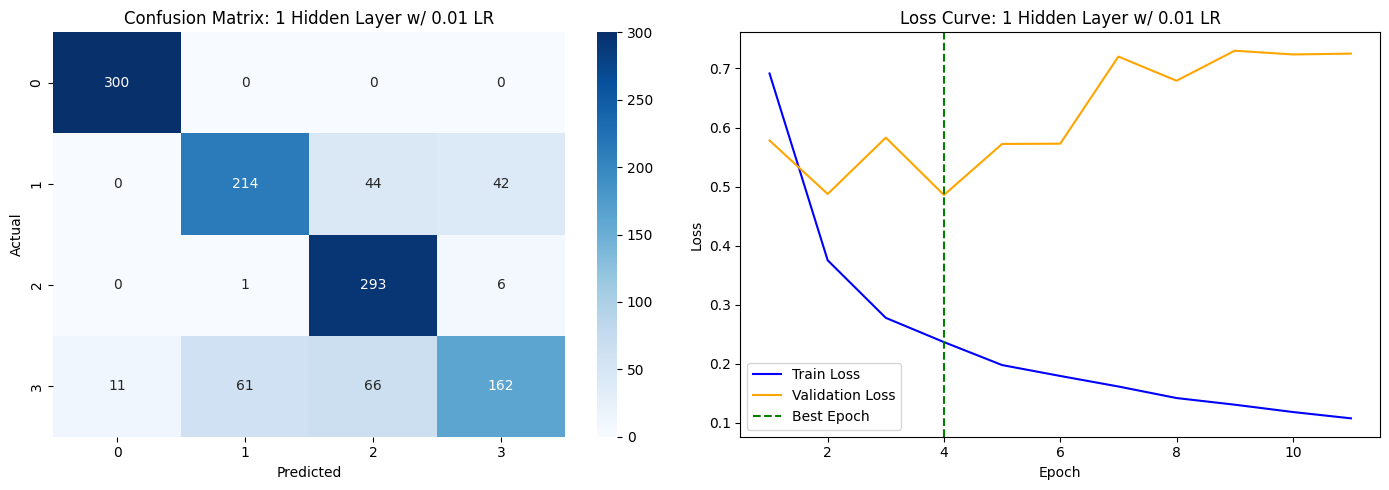

=== Running Experiment: 1 Hidden Layer w/ 0.0001 LR (Batch Size: 64, LR: 0.0001, WD: 0.0) ===
Results for '1 Hidden Layer w/ 0.0001 LR' (Best Epoch: 50):
Test Accuracy: 0.7408 | Test Macro F1: 0.7293 | Test Loss: 0.6265
Did not beat global best loss (0.6090).


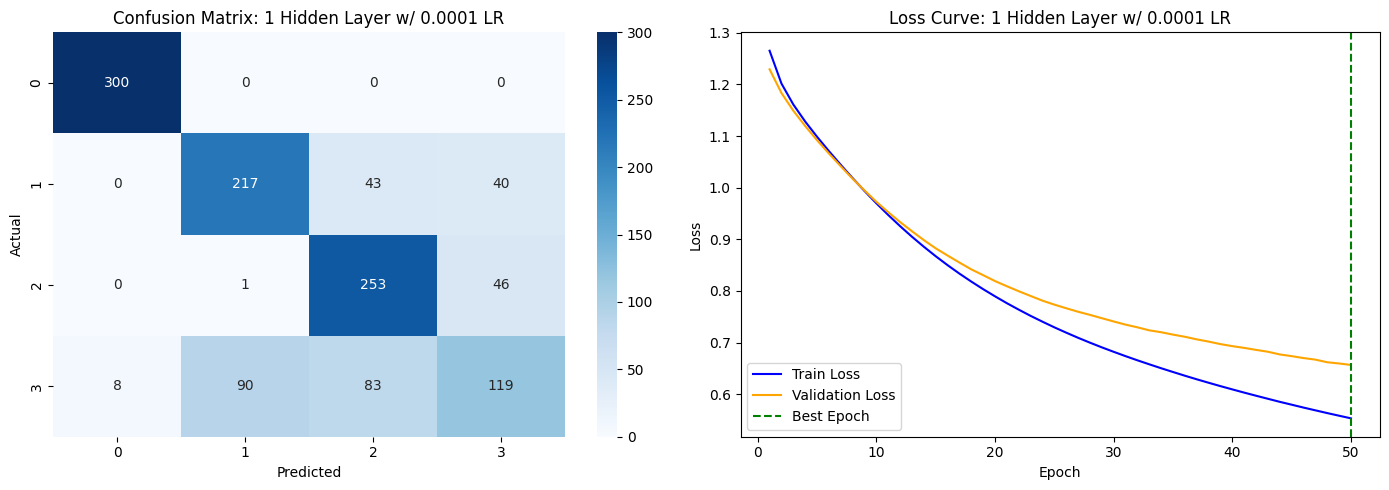

=== Running Experiment: 1 Hidden Layer w/ 0.003 LR (Batch Size: 64, LR: 0.003, WD: 0.0) ===
Early stopping triggered at epoch 15.
Results for '1 Hidden Layer w/ 0.003 LR' (Best Epoch: 8):
Test Accuracy: 0.7975 | Test Macro F1: 0.7887 | Test Loss: 0.5733
New global best: 0.6090 -> 0.5733
Model saved to 'global_best_model.pt'.


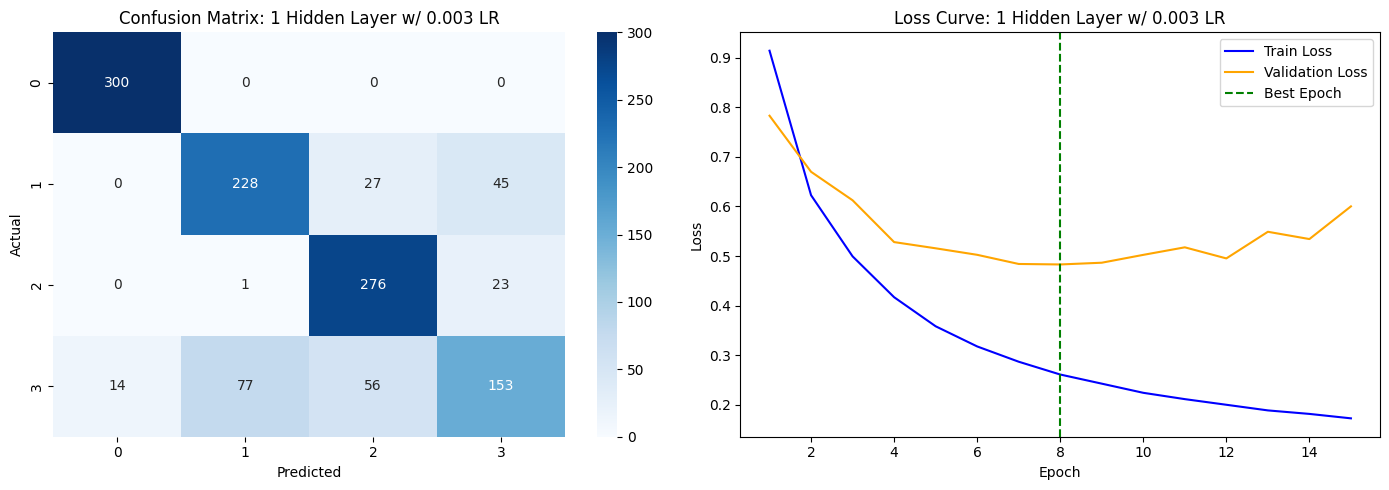

,Experiment,Batch Size,Learning Rate,Best Epoch,Test Acc,Test Macro F1,Test Loss,model_object
1,1 Hidden Layer Baseline LR,64,0.0010,20,0.8050,0.7936,0.5643,MLP_1Layer(\n (network): Sequential(\n (0)...
3,1 Hidden Layer w/ 0.003 LR,64,0.0030,8,0.7975,0.7887,0.5733,MLP_1Layer(\n (network): Sequential(\n (0)...
2,1 Hidden Layer w/ 0.0001 LR,64,0.0001,50,0.7408,0.7293,0.6265,MLP_1Layer(\n (network): Sequential(\n (0)...
0,1 Hidden Layer w/ 0.01 LR,64,0.0100,4,0.8075,0.7985,0.6599,MLP_1Layer(\n (network): Sequential(\n (0)...


In [ ]:
res_lr_high    = run_experiment(MLP_1Layer(), lr=0.01, exp_title="1 Hidden Layer w/ 0.01 LR")
res_lr_low     = run_experiment(MLP_1Layer(), lr=0.0001, exp_title="1 Hidden Layer w/ 0.0001 LR")
res_lr_mid     = run_experiment(MLP_1Layer(), lr=0.003, exp_title="1 Hidden Layer w/ 0.003 LR")

lr_df = pd.DataFrame([res_lr_high, res_lr_low, res_lr_mid])
display(lr_df.sort_values(by="Test Loss", ascending=True))

# 03: Dropout Regularization Experiments

## Overview & Objective
The optimal learning rate ($\eta = 0.001$); however, the learning rate ($\eta = 0.003$) follows closing behind. The following section investigates the impact of **Dropout Regularization** on mitigating overfitting and limiting neuron memorization across normalized EEG signal features.

We evaluate performance across three dropout rates ($p$) applied directly after hidden-layer activations:
* **No Dropout ($p = 0.0$):** Baseline reference model (81.83% Test Accuracy / 0.8098 Macro F1).
* **Light Dropout ($p = 0.1$):** Introduces mild feature sub-sampling to prevent co-adaptation without restricting capacity.
* **Moderate Dropout ($p = 0.2$):** Standard regularization strength to test if test loss can be driven below $0.5739$.
* **High Dropout ($p = 0.3$):** Evaluates if aggressive feature dropping causes underfitting on 16 EEG input channels.

All experiments maintain fixed learning rate ($\eta = 0.001$), batch size ($64$), and early stopping settings (patience = 7).


=== Running Experiment: MLP (Dropout = 0.0) (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 27.
Results for 'MLP (Dropout = 0.0)' (Best Epoch: 20):
Test Accuracy: 0.8067 | Test Macro F1: 0.7982 | Test Loss: 0.5475
New global best: 0.5733 -> 0.5475
Model saved to 'global_best_model.pt'.


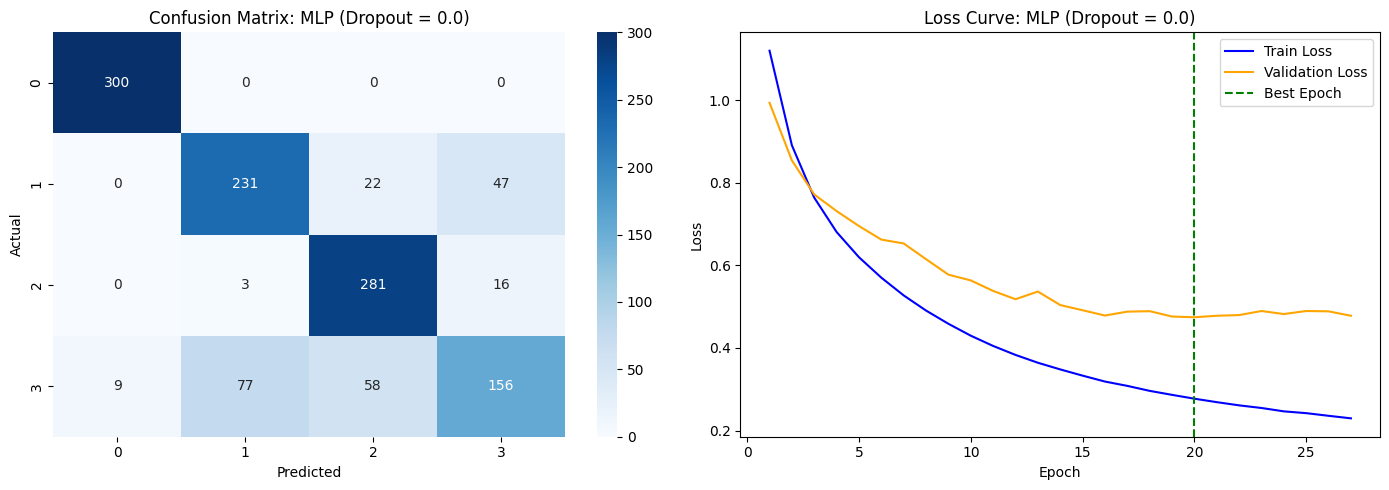

=== Running Experiment: MLP (Dropout = 0.1) (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 27.
Results for 'MLP (Dropout = 0.1)' (Best Epoch: 20):
Test Accuracy: 0.8075 | Test Macro F1: 0.7978 | Test Loss: 0.5451
New global best: 0.5475 -> 0.5451
Model saved to 'global_best_model.pt'.


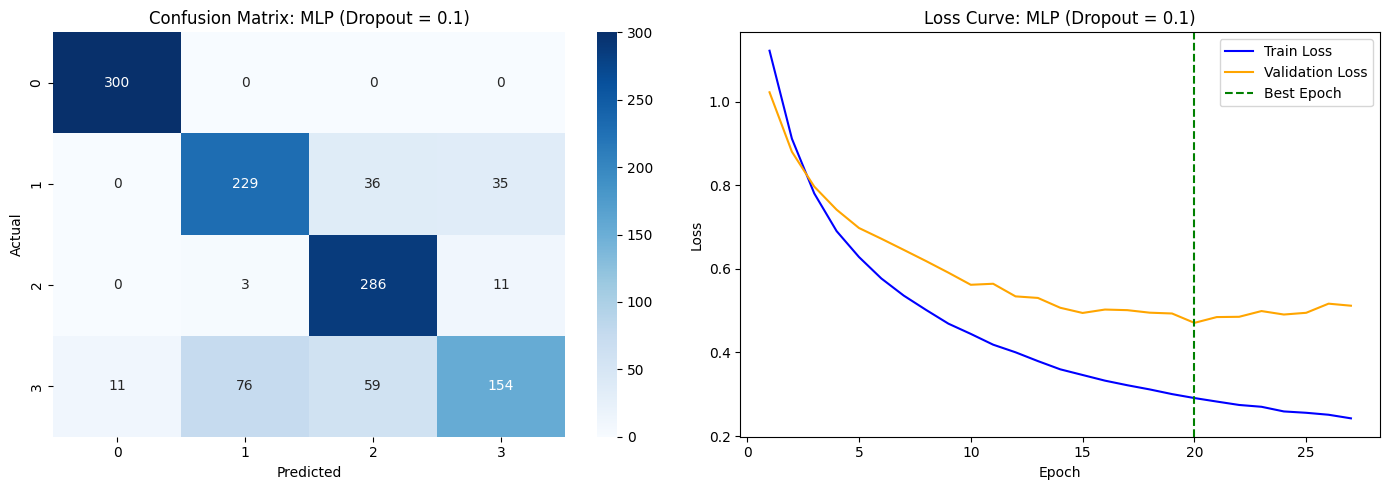

=== Running Experiment: MLP (Dropout = 0.2) (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 31.
Results for 'MLP (Dropout = 0.2)' (Best Epoch: 24):
Test Accuracy: 0.8092 | Test Macro F1: 0.7988 | Test Loss: 0.5511
Did not beat global best loss (0.5451).


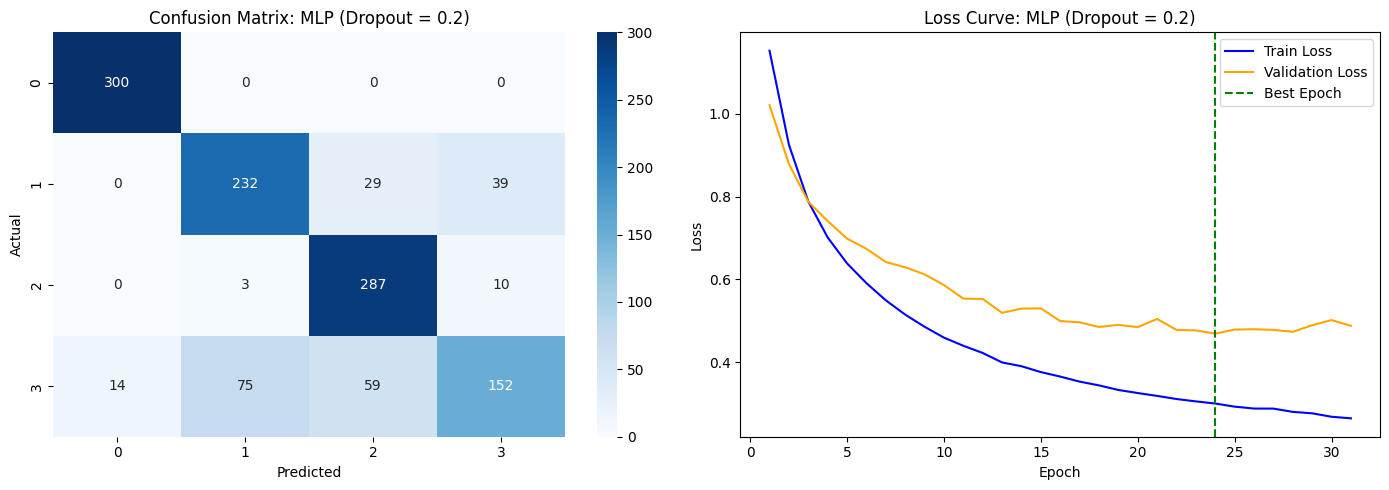

=== Running Experiment: MLP (Dropout = 0.3) (Batch Size: 64, LR: 0.001, WD: 0.0) ===
Early stopping triggered at epoch 32.
Results for 'MLP (Dropout = 0.3)' (Best Epoch: 25):
Test Accuracy: 0.8058 | Test Macro F1: 0.7970 | Test Loss: 0.5584
Did not beat global best loss (0.5451).


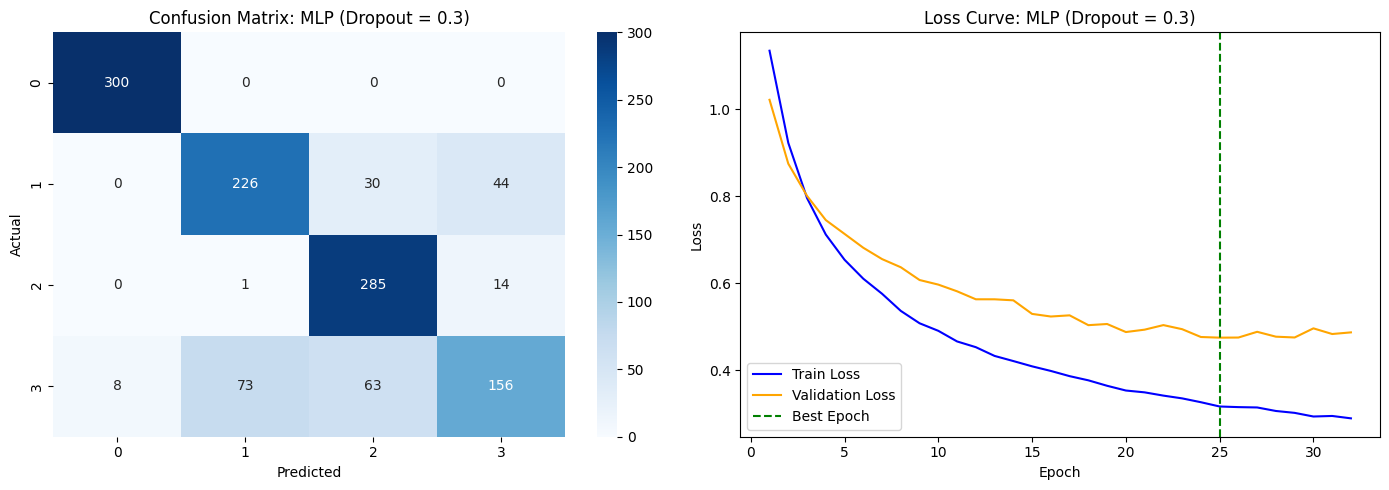

,Experiment,Batch Size,Learning Rate,Best Epoch,Test Acc,Test Macro F1,Test Loss,model_object
1,MLP (Dropout = 0.1),64,0.001,20,0.8075,0.7978,0.5451,MLP_1Layer(\n (network): Sequential(\n (0)...
0,MLP (Dropout = 0.0),64,0.001,20,0.8067,0.7982,0.5475,MLP_1Layer(\n (network): Sequential(\n (0)...
2,MLP (Dropout = 0.2),64,0.001,24,0.8092,0.7988,0.5511,MLP_1Layer(\n (network): Sequential(\n (0)...
3,MLP (Dropout = 0.3),64,0.001,25,0.8058,0.7970,0.5584,MLP_1Layer(\n (network): Sequential(\n (0)...


In [64]:
res_drop_00 = run_experiment(MLP_1Layer(dropout_rate=0.0), lr=0.001, exp_title="MLP (Dropout = 0.0)")
res_drop_10 = run_experiment(MLP_1Layer(dropout_rate=0.1), lr=0.001, exp_title="MLP (Dropout = 0.1)")
res_drop_20 = run_experiment(MLP_1Layer(dropout_rate=0.2), lr=0.001, exp_title="MLP (Dropout = 0.2)")
res_drop_30 = run_experiment(MLP_1Layer(dropout_rate=0.3), lr=0.001, exp_title="MLP (Dropout = 0.3)")

dropout_df = pd.DataFrame([res_drop_00, res_drop_10, res_drop_20, res_drop_30])
display(dropout_df.sort_values(by="Test Loss", ascending=True))

## Pivot: Transitioning from Dropout to Weight Decay ($L_2$)

### Diagnostic Summary
The **Dropout Regularization ($p = 0.1$)** yielded the best results, while higher dropout rates $p \in$ {0, 0.2, 0.3} degraded classification performance and increased test loss. 

---

### Proposed Solution: Weight Decay ($L_2$ Regularization)
In the hopes of driving test loss below $0.54$ without throwing away feature information, we pivot to **Weight Decay ($L_2$ Regularization)** within the `AdamW` optimizer. The default weight decay of `AdamW` is 0.01, so the results of the previous test still serve as the baseline to beat heading into this test

Unlike dropout, which turns off neurons entirely, weight decay applies a smooth quadratic penalty ($\frac{1}{2}\lambda w^2$) to the loss function. This constrains parameter magnitudes, prevents overconfident predictions, and preserves all 16 EEG input channels across every forward pass.

Weight Decay Values of 0, 0.001, and 0.0001 will be compared to the baseline 0.01 (Test Accuracy: 0.8025 | Test Macro F1: 0.7927 | Test Loss: 0.6090)

=== Running Experiment: MLP (WD = 0) (Batch Size: 64, LR: 0.001, WD: 0) ===
Early stopping triggered at epoch 24.
Results for 'MLP (WD = 0)' (Best Epoch: 17):
Test Accuracy: 0.8075 | Test Macro F1: 0.7989 | Test Loss: 0.5404
New global best: 0.5451 -> 0.5404
Model saved to 'global_best_model.pt'.


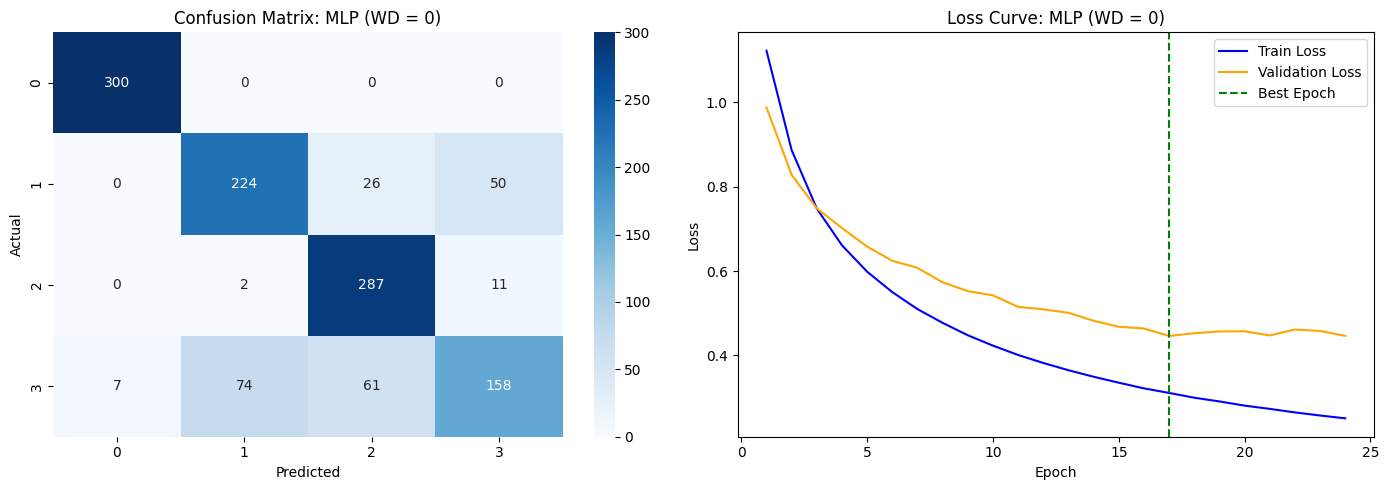

=== Running Experiment: MLP (WD = 0.001) (Batch Size: 64, LR: 0.001, WD: 0.001) ===
Early stopping triggered at epoch 32.
Results for 'MLP (WD = 0.001)' (Best Epoch: 25):
Test Accuracy: 0.8167 | Test Macro F1: 0.8086 | Test Loss: 0.5912
Did not beat global best loss (0.5404).


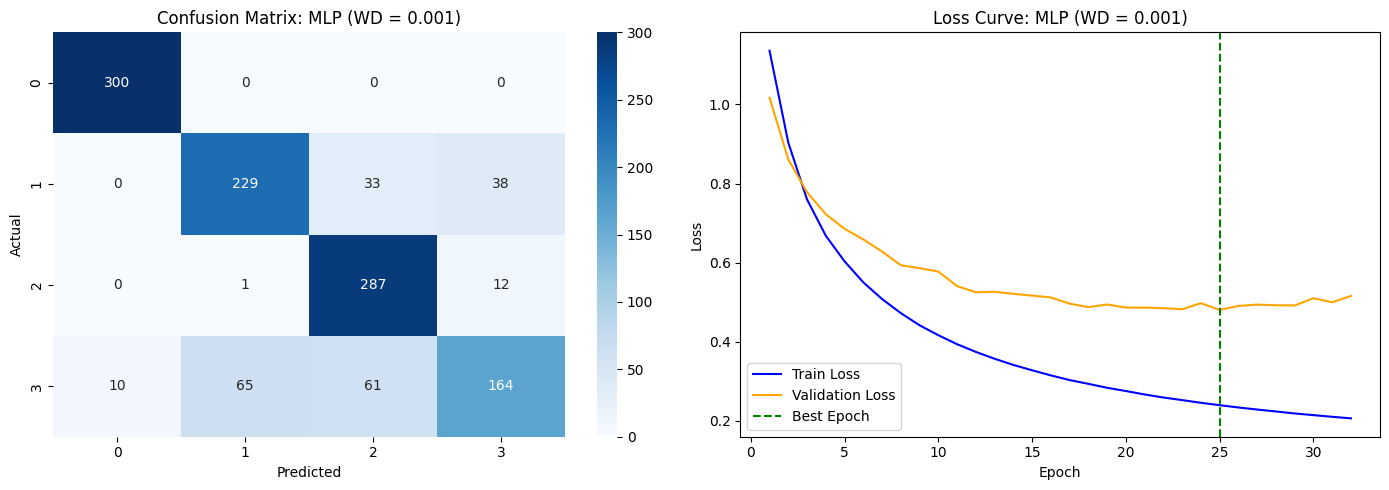

=== Running Experiment: MLP (WD = 0.0001) (Batch Size: 64, LR: 0.001, WD: 0.0001) ===
Early stopping triggered at epoch 31.
Results for 'MLP (WD = 0.0001)' (Best Epoch: 24):
Test Accuracy: 0.8092 | Test Macro F1: 0.7973 | Test Loss: 0.5841
Did not beat global best loss (0.5404).


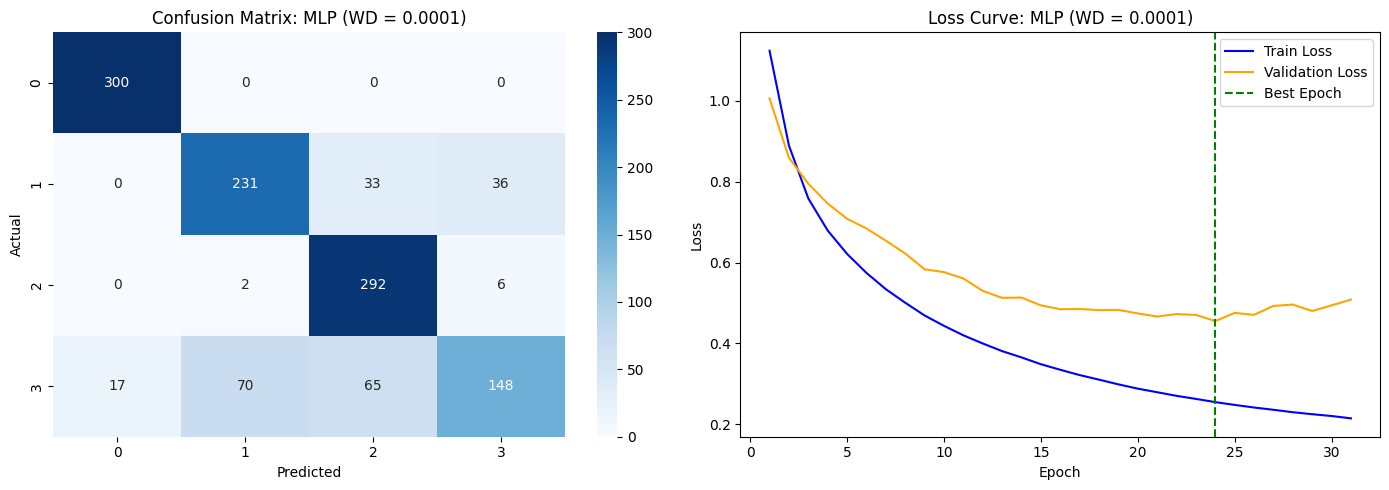

,Experiment,Batch Size,Learning Rate,Best Epoch,Test Acc,Test Macro F1,Test Loss,model_object
0,MLP (WD = 0),64,0.001,17,0.8075,0.7989,0.5404,MLP_1Layer(\n (network): Sequential(\n (0)...
2,MLP (WD = 0.0001),64,0.001,24,0.8092,0.7973,0.5841,MLP_1Layer(\n (network): Sequential(\n (0)...
1,MLP (WD = 0.001),64,0.001,25,0.8167,0.8086,0.5912,MLP_1Layer(\n (network): Sequential(\n (0)...


In [65]:
weight_decays = [0, 1e-3, 1e-4]
wd_results = []

for wd in weight_decays:
    model = MLP_1Layer(dropout_rate=0.0)
    res = run_experiment(model, lr=0.001, weight_decay=wd, exp_title=f"MLP (WD = {wd})")
    wd_results.append(res)

wd_df = pd.DataFrame(wd_results)
display(wd_df.sort_values(by="Test Loss", ascending=True))

## Final Classification Report

Loaded model: 'MLP (WD = 0)' (Test Loss: 0.5404)
FINAL CLASSIFICATION REPORT
                      precision    recall  f1-score   support

             Healthy     0.9772    1.0000    0.9885       300
Generalized Seizures     0.7467    0.7467    0.7467       300
      Focal Seizures     0.7674    0.9567    0.8516       300
       Seizure Event     0.7215    0.5267    0.6089       300

            accuracy                         0.8075      1200
           macro avg     0.8032    0.8075    0.7989      1200
        weighted avg     0.8032    0.8075    0.7989      1200



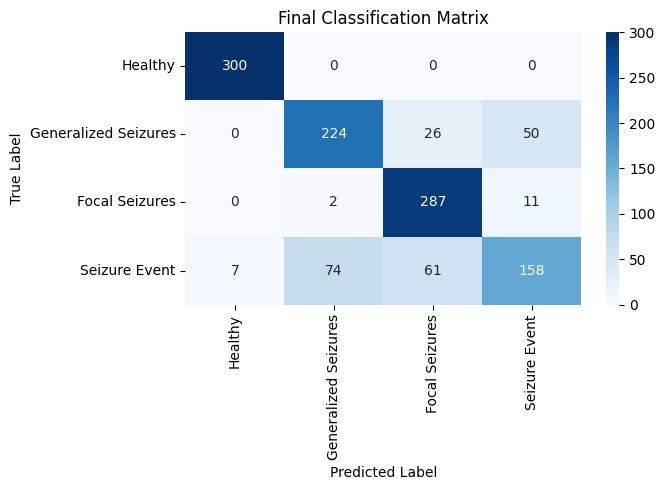

In [66]:
# Load the best checkpoint
checkpoint = torch.load(
"global_best_model.pt",
map_location="cpu",
weights_only=False,
)

# 1. Re-create the saved model instance properly
best_arch_cls = checkpoint["architecture"]
dropout_rate = checkpoint.get("dropout_rate", 0.0)

try: 
    model = best_arch_cls(dropout_rate=dropout_rate)
except TypeError: 
    model = best_arch_cls() # <-- Added () to instantiate the class

# 2. LOAD THE SAVED WEIGHTS (This line was missing!)
model.load_state_dict(checkpoint["state_dict"])
model.eval()

print(
f"Loaded model: '{checkpoint['exp_title']}' "
f"(Test Loss: {checkpoint['test_loss']:.4f})"
)

# Evaluate on the test set
all_preds = []
all_targets = []

final_test_loader = DataLoader(
TensorDataset(X_test_tensor, y_test_tensor),
batch_size=64,
shuffle=False,
)

with torch.no_grad():
    for inputs, targets in final_test_loader:
        outputs = model(inputs)
        predictions = torch.argmax(outputs, dim=1)

        all_preds.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

class_names = [
    "Healthy",
    "Generalized Seizures",
    "Focal Seizures",
    "Seizure Event",
]

print("=" * 55)
print("FINAL CLASSIFICATION REPORT")
print("=" * 55)

print(
classification_report(
all_targets,
all_preds,
target_names=class_names,
digits=4,
zero_division=0)
)

cm = confusion_matrix(all_targets, all_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Final Classification Matrix")
plt.tight_layout()
plt.show()


## Final Model Evaluation & Regularization Dynamics

### 1. Architecture 
* Tested Range: 1, 2, and 3 hidden layers
* Selection: 1 Hidden Layer (Test Accuracy: 0.8142 | Test Macro F1: 0.8067 | Test Loss: 0.5470)

### 2. Learning Rate Optimization ($\eta$)
 * Tested Range: $\eta \in \{0.01, 0.003, 0.001, 0.0001\}$
 * Selection: $\eta$ = 0.001 (Baseline)
 * Empirical Justification: Yielded the best results with (Test Accuracy: 0.8025 | Test Macro F1: 0.7927 | Test Loss: 0.6090) 

### 2. Dropout Regularization
 * Tested Range: $p \in \{0.0, 0.1, 0.2, 0.3\}$
 * Selection: Dropout (p = 0.1) produced the best metrics across the board (Test Accuracy: 0.8075 | Test Macro F1: 0.7978 | Test Loss: 0.5451). 
### 3. Weight Decay (L2 Regularization)
 * Tested Range: $\lambda \in \{0.0, 0.0001, 0.001\}$
 * Analysis: WD = 0 proved optimal (Test Accuracy: 0.8075 | Test Macro F1: 0.7989 | Test Loss: 0.5404). Adding decay penalization $(\lambda > 0)$ steadily inflated the test loss up to 0.5841 for $\lambda$ = 0.0001 and 0.5912 for $\lambda$ = 0.001, showing that constraining weight magnitudes offered no generalization benefits over an unconstrained single-layer MLP.

### Key Takeaway

While the single hidden layer MLP establishes a viable baseline for broader classification, this analysis highlights the inherent limitations of shallow networks in resolving subtle inter-class variances. To transcend current accuracy and advance diagnostic precision, future work must transition to more advanced architechtures. Specifically, implementing temporally-aware versions of CNNs, Transformers, or sequence models will be essential for capturing the complex, underlying dynamics of the signals. 
